# Defensive Momentum — the quant teardown 🛟

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

**Claim under test:** a 50/50 (or inverse-vol) blend of MTUM (momentum) and USMV (min-vol) delivers a **higher excess-of-cash Sharpe** and **shallower momentum-crash drawdowns** than MTUM alone, net of costs.

**Dedup guard:** [508-momentum-crashes](../../508-momentum-crashes/) grades the crash *mechanism*; [330-low-volatility-anomaly](../../330-low-volatility-anomaly/) the low-vol anomaly; [601-factor-etf-live-test](../../601-factor-etf-live-test/) the *single* live wrappers; [237-residual-momentum](../../237-residual-momentum/) a *different* crash fix. This study grades the **blend**.

**Method skeleton.** Monthly total returns (yfinance auto-adjusted), sliced to the last complete month (2026-06-30); excess = minus the BIL cash leg. Blend window = MTUM's 2013-05 inception → 2026-06 (158 months). Two blends: fixed **50/50** monthly-rebalanced, and **inverse-trailing-12m-vol** with weights formed at *t−1* (one lag, no look-ahead). The excess-vs-excess **Sharpe advantage** vs MTUM, the **Newey-West** *t* on the monthly return difference, a moving-block **bootstrap CI** on the advantage; max drawdown + named crash windows; an **era cut**; a **costed** net series (one-way cost × realized turnover; long-only, no borrow).

Frozen headline run: [`docs/results.md`](../docs/results.md), as-of 2026-06-30, fingerprint `7d4dcacd42bd`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from def_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    MRET = data.monthly_total_returns(PRICES)
    CASH = MRET[data.CASH]
    SLEEVES = MRET[data.SLEEVES].dropna()
    COMMON = SLEEVES.index
    FIFTY = st.fixed_blend(SLEEVES, 0.5)
    VOLW = st.vol_weighted_blend(SLEEVES, lookback=12, lag=1)
    def ex(col):
        return st.excess(MRET, col).reindex(COMMON).dropna()
else:
    PRICES = MRET = CASH = SLEEVES = COMMON = FIFTY = VOLW = None
print("real cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '7d4dcacd42bd', 'n': 158, 'win': '2013-05 -> 2026-06', 'strat': {'MTUM': {'cagr': 16.8, 'vol': 16.3, 'sh': 0.941, 'dd': -30.2, 'w': 7.72}, 'USMV': {'cagr': 10.4, 'vol': 11.5, 'sh': 0.775, 'dd': -19.1, 'w': 3.68}, 'QUAL': {'cagr': 13.75, 'vol': 14.7, 'sh': 0.841, 'dd': -27.8, 'w': 5.28}, 'SPY': {'cagr': 14.38, 'vol': 14.4, 'sh': 0.895, 'dd': -23.9, 'w': 5.86}, 'BLEND': {'cagr': 13.7, 'vol': 13.1, 'sh': 0.924, 'dd': -22.2, 'w': 5.42}, 'BLEND_NET': {'cagr': 13.69, 'vol': 13.1, 'sh': 0.924, 'dd': -22.2, 'w': 5.42}, 'VOLW': {'cagr': 12.98, 'vol': 12.9, 'sh': 0.875, 'dd': -21.9, 'w': 4.41}}, 'race': {'fifty': {'n': 158, 'sh_bl': 0.924, 'sh_mt': 0.941, 'adv': -0.016, 'diff': -26.4, 't_nw': -1.88, 't_1s': -2.21, 'lo': -0.139, 'hi': 0.164, 'p': 0.573, 'net_adv': -0.017}, 'volw': {'n': 146, 'sh_bl': 0.875, 'sh_mt': 0.919, 'adv': -0.044, 'diff': -32.4, 't_nw': -1.73, 't_1s': -2.1, 'lo': -0.175, 'hi': 0.188, 'p': 0.524, 'net_adv': -0.045}}, 'crash': {'full': (-30.2, -22.2, -19.1), 'covid': (-17.9, -18.5, -19.1), 'bear22': (-21.2, -17.7, -14.1), 'q4_18': (-15.4, -11.6, -7.6)}, 'era': {'early': {'win': '2013-05..2019-11', 'n': 79, 'adv': 0.082, 'diff': -11.6, 't': -1.06}, 'late': {'win': '2019-12..2026-06', 'n': 79, 'adv': -0.102, 'diff': -41.2, 't': -1.62}}, 'cal': {2013: (17.1, 7.5, 12.2, 17.5), 2014: (14.6, 16.3, 15.5, 13.5), 2015: (8.9, 5.4, 7.2, 1.2), 2016: (5.0, 10.6, 7.8, 12.0), 2017: (37.5, 18.9, 27.9, 21.7), 2018: (-1.7, 1.3, -0.1, -4.6), 2019: (27.3, 27.7, 27.5, 31.2), 2020: (29.9, 5.6, 17.3, 18.3), 2021: (13.4, 20.8, 17.3, 28.7), 2022: (-18.3, -9.4, -13.8, -18.2), 2023: (9.1, 10.3, 9.8, 26.2), 2024: (32.9, 15.7, 24.2, 24.9), 2025: (22.1, 7.6, 15.0, 17.7), 2026: (37.2, 3.2, 19.6, 10.1)}, 'turnover': {'fifty': 1.03, 'volw': 3.2}, 'syn': {'null': {'adv': 0.0, 'dd_bl': -27.7, 'dd_mt': -27.7}, 'planted': {'adv': 0.242, 't': 2.56, 'diff': 36.8, 'dd_bl': -48.0, 'dd_mt': -67.6}}}


real cache present: True


## 0 · Data stamp (cache-first, deterministic)

In [2]:
if HAVE_REAL:
    try:
        from quantlab import repro
        panel = MRET[data.TICKERS].loc[COMMON]
        print('fingerprint:', repro.fingerprint(panel), '(frozen:', R['fingerprint'] + ')')
    except Exception as e:
        print('quantlab.repro unavailable:', e)
    print('blend window:', COMMON.min().date(), '->', COMMON.max().date(), f'({len(COMMON)} months)')
    for tk in data.TICKERS:
        s = MRET[tk].dropna()
        print(f'  {tk}: {s.index.min().date()} -> {s.index.max().date()}  ({len(s)} months)')
else:
    print('cache missing — the frozen numbers in R carry the notebook')


fingerprint: 7d4dcacd42bd (frozen: 7d4dcacd42bd)
blend window: 2013-05-31 -> 2026-06-30 (158 months)
  MTUM: 2013-05-31 -> 2026-06-30  (158 months)
  USMV: 2011-11-30 -> 2026-06-30  (176 months)
  QUAL: 2013-08-31 -> 2026-06-30  (155 months)
  SPY: 2007-02-28 -> 2026-06-30  (233 months)
  BIL: 2007-06-30 -> 2026-06-30  (229 months)


> 💡 **In plain words:** the fingerprint is a hash of the exact monthly panel behind the published verdict — a matching 12 characters means you hold byte-for-byte the same data. Note the blend is **MTUM-inception-limited**: USMV runs to 176 months but the blend can only start where *both* sleeves exist (2013-05).

## 1 · The strategy table (excess-of-cash, same 158-month window)

CAGR, annualised vol, excess Sharpe and max drawdown for each sleeve, the blends, QUAL and SPY.

In [3]:
if HAVE_REAL:
    def row(name, r):
        a = st.ann_stats(r.reindex(COMMON).dropna(), CASH)
        return [name, a['cagr']*100, a['vol']*100, a['sharpe'], a['maxdd']*100, a['wealth']]
    rows = [row('MTUM', MRET['MTUM']), row('USMV', MRET['USMV']), row('QUAL', MRET['QUAL']),
            row('SPY', MRET['SPY']), row('50/50 blend', FIFTY['gross']),
            row('50/50 net', st.apply_costs(FIFTY, 3.0)),
            row('inv-vol blend', VOLW['gross']), row('inv-vol net', st.apply_costs(VOLW, 3.0))]
    print(pd.DataFrame(rows, columns=['strategy','CAGR%','vol%','exSharpe','maxDD%','$1'])
          .round(3).to_string(index=False))
else:
    for k,v in R['strat'].items():
        print(k, v)


     strategy  CAGR%   vol%  exSharpe  maxDD%    $1
         MTUM 16.798 16.271     0.941 -30.170 7.725
         USMV 10.398 11.522     0.775 -19.056 3.678
         QUAL 13.746 14.674     0.841 -27.782 5.279
          SPY 14.377 14.409     0.895 -23.927 5.863
  50/50 blend 13.700 13.106     0.924 -22.213 5.422
    50/50 net 13.693 13.106     0.924 -22.215 5.418
inv-vol blend 12.979 12.921     0.875 -21.878 4.414
  inv-vol net 12.964 12.921     0.874 -21.885 4.406


The blend's excess Sharpe (**0.924**) sits *between* USMV (0.775) and MTUM (0.941) — a weighted average, not a lift above either. Vol drops to 13.1% (from 16.3%); CAGR drops to 13.7% (from 16.8%). Risk and return fall together, in lockstep.

## 2 · The headline race — excess-vs-excess Sharpe advantage vs MTUM

Both legs excess-of-cash. The Sharpe **advantage** answers 'is the blend a better risk-adjusted deal?'; the **Newey-West *t*** on the mean monthly return difference answers 'is that gap distinguishable from zero?'. A moving-block bootstrap (block 6) puts a CI on the advantage — light draws in-notebook; the canonical 2,000-draw numbers are quoted from `R`.

In [4]:
if HAVE_REAL:
    mt_ex = ex('MTUM')
    for label, blend in [('50/50', FIFTY), ('inv-vol', VOLW)]:
        bl_ex = (blend['gross'] - CASH).reindex(COMMON).dropna()
        idx = bl_ex.index.intersection(mt_ex.index)
        race = st.sharpe_advantage(bl_ex.loc[idx], mt_ex.loc[idx])
        boot = st.bootstrap_sharpe_adv(bl_ex.loc[idx], mt_ex.loc[idx], n_draws=400, seed=895)
        print(f"{label}: exSharpe {race['sharpe_a']:.3f} vs MTUM {race['sharpe_b']:.3f}  "
              f"adv {race['sharpe_adv']:+.3f}  diff {race['diff_bps']:+.1f} bps/mo  "
              f"NW t {race['t_nw']:+.2f}  boot(400) CI [{boot['lo']:+.3f},{boot['hi']:+.3f}]")
    print('\n(canonical 2,000-draw CIs are in R / docs/results.md)')
else:
    print('cache missing')
for label, k in [('50/50', 'fifty'), ('inv-vol', 'volw')]:
    d = R['race'][k]
    print(f"[R] {label}: adv {d['adv']:+.3f}  diff {d['diff']:+.1f} bps  NW t {d['t_nw']:+.2f}  "
          f"1s t {d['t_1s']:+.2f}  boot CI [{d['lo']:+.3f},{d['hi']:+.3f}]  P(adv>0) {d['p']:.3f}")


50/50: exSharpe 0.924 vs MTUM 0.941  adv -0.016  diff -26.4 bps/mo  NW t -1.88  boot(400) CI [-0.141,+0.157]


inv-vol: exSharpe 0.875 vs MTUM 0.919  adv -0.044  diff -32.4 bps/mo  NW t -1.73  boot(400) CI [-0.164,+0.169]

(canonical 2,000-draw CIs are in R / docs/results.md)
[R] 50/50: adv -0.016  diff -26.4 bps  NW t -1.88  1s t -2.21  boot CI [-0.139,+0.164]  P(adv>0) 0.573
[R] inv-vol: adv -0.044  diff -32.4 bps  NW t -1.73  1s t -2.10  boot CI [-0.175,+0.188]  P(adv>0) 0.524


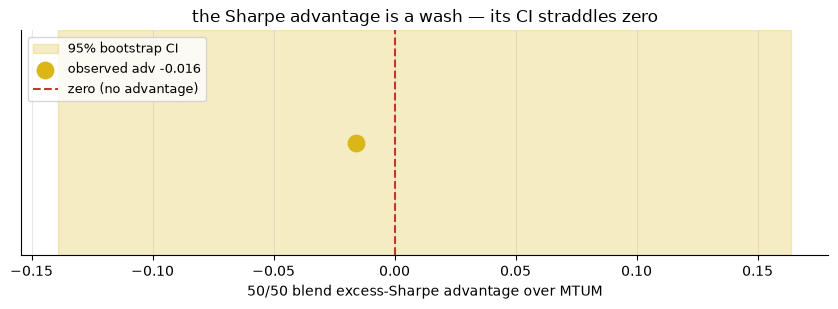

P(advantage > 0) under the bootstrap = 0.573  -> a coin flip
but the RETURN give-up is robust: -26.4 bps/mo, one-sample t -2.21


In [5]:
d = R['race']['fifty']
fig, ax = plt.subplots(figsize=(8.5,3.2))
# the bootstrap CI on the Sharpe advantage, against the zero line
ax.axvspan(d['lo'], d['hi'], color=AMBER, alpha=.25, label='95% bootstrap CI')
ax.scatter([d['adv']], [0], s=140, color=AMBER, zorder=3, label=f"observed adv {d['adv']:+.3f}")
ax.axvline(0, color=RED, lw=1.5, ls='--', label='zero (no advantage)')
ax.set_yticks([]); ax.set_xlabel('50/50 blend excess-Sharpe advantage over MTUM')
ax.set_title('the Sharpe advantage is a wash — its CI straddles zero')
ax.legend(fontsize=9, loc='upper left'); plt.tight_layout(); plt.show()
print(f"P(advantage > 0) under the bootstrap = {d['p']:.3f}  -> a coin flip")
print(f"but the RETURN give-up is robust: {d['diff']:+.1f} bps/mo, one-sample t {d['t_1s']:+.2f}")


The claimed *higher* Sharpe is not there: the 50/50 advantage is **−0.016**, its bootstrap CI is **[−0.14, +0.16]**, and P(adv>0) ≈ **0.57** — a coin flip. What *is* robust is the return the blend **surrenders**: −26 bps/mo (one-sample *t* −2.21), the mechanical cost of holding less momentum. Costs don't enter into it — at 3 bps/side and ~1%/mo turnover the **net** advantage (−0.017) equals the gross.

## 3 · Crash geometry — the drawdown grid

Worst peak-to-trough inside each named window. The full-window reduction is real; the per-crash story is not uniform.

In [6]:
if HAVE_REAL:
    wins = [('full', COMMON.min().strftime('%Y-%m-%d'), COMMON.max().strftime('%Y-%m-%d')),
            ('2020 COVID', '2020-01-01', '2020-06-30'),
            ('2022 bear', '2022-01-01', '2022-12-31'),
            ('2018 Q4', '2018-09-01', '2018-12-31')]
    for lab, s, e in wins:
        m = st.window_drawdown(MRET['MTUM'].reindex(COMMON), s, e)
        b = st.window_drawdown(FIFTY['gross'].reindex(COMMON), s, e)
        u = st.window_drawdown(MRET['USMV'].reindex(COMMON), s, e)
        flag = 'blend helped' if b > m else 'blend did NOT help'
        print(f"{lab:11s}: MTUM {m*100:6.1f}%  50/50 {b*100:6.1f}%  USMV {u*100:6.1f}%   -> {flag}")
else:
    for k in ['full','covid','bear22','q4_18']:
        print(k, R['crash'][k])


full       : MTUM  -30.2%  50/50  -22.2%  USMV  -19.1%   -> blend helped
2020 COVID : MTUM  -17.9%  50/50  -18.5%  USMV  -19.1%   -> blend did NOT help
2022 bear  : MTUM  -21.2%  50/50  -17.7%  USMV  -14.1%   -> blend helped
2018 Q4    : MTUM  -15.4%  50/50  -11.6%  USMV   -7.6%   -> blend helped


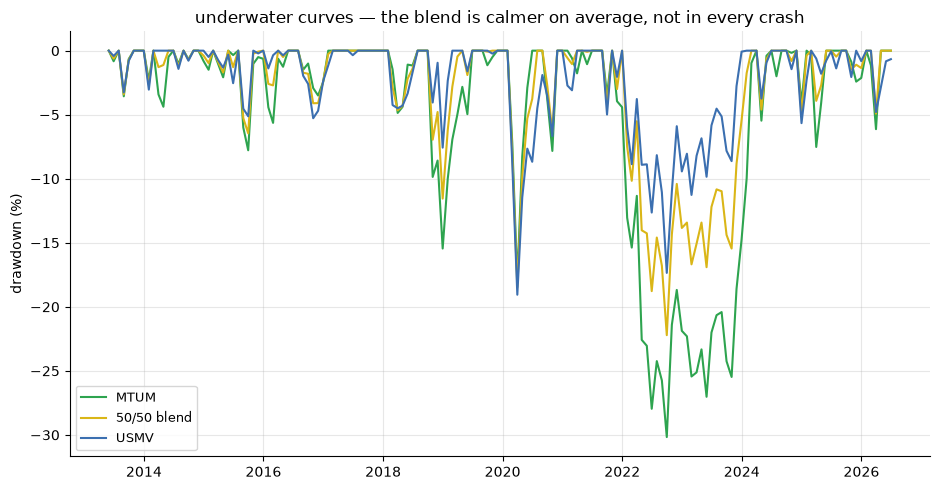

In [7]:
if HAVE_REAL:
    fig, ax = plt.subplots()
    for name, c in [('MTUM', GREEN), ('50/50 blend', AMBER), ('USMV', BLUE)]:
        r = (FIFTY['gross'] if name=='50/50 blend' else MRET[name.split()[0]]).reindex(COMMON).dropna()
        ax.plot(st.drawdown_curve(r)*100, color=c, lw=1.5, label=name)
    ax.set_ylabel('drawdown (%)'); ax.set_title('underwater curves — the blend is calmer on average, not in every crash')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()
else:
    print('cache missing — see docs/results.md drawdown table')


The blend's underwater curve is shallower **on average**, but in **2020** it dips *below* MTUM's — min-vol drew down −19.1%, the worst of the three, in the fastest crash on the tape. A defensive overlay that abandons you in the sharpest sell-off is not a dependable crash hedge.

## 4 · Era cut — is the (absent) edge at least stable? No.

Split the 158 months in half; recompute the Sharpe advantage in each.

In [8]:
if HAVE_REAL:
    mt_ex = ex('MTUM')
    bl_ex = (FIFTY['gross'] - CASH).reindex(COMMON).dropna()
    idx = bl_ex.index.intersection(mt_ex.index)
    eras = st.era_split(bl_ex.loc[idx], mt_ex.loc[idx])
    for nm in ('early','late'):
        e = eras[nm]
        print(f"{nm:5s} {e['start']}..{e['end']} ({e['n']}m): Sharpe adv {e['sharpe_adv']:+.3f}  "
              f"diff {e['diff_bps']:+.1f} bps  NW t {e['t_nw']:+.2f}")
else:
    for nm in ('early','late'):
        print(nm, R['era'][nm])


early 2013-05-31..2019-11-30 (79m): Sharpe adv +0.082  diff -11.6 bps  NW t -1.06
late  2019-12-31..2026-06-30 (79m): Sharpe adv -0.102  diff -41.2 bps  NW t -1.62


The tiny advantage **flips sign**: mildly positive when momentum was choppy (2013-19, **+0.082**), clearly negative in the momentum-led 2020s (**−0.102**). Not robust in sign, let alone magnitude — the opposite of what a real edge does.

## 5 · Synthetic control — the machinery is faithful

A deterministic joint (momentum, min-vol, bench, cash) monthly world with a tunable planted crash/diversification `edge` (`data.synthetic_sleeves`). On the null the two sleeves are the *same series*, so the blend is exactly a sleeve — the estimator must return zero. On a planted edge it must recover a positive Sharpe advantage and a shallower blend drawdown. Runs anywhere, no network.

In [9]:
for label, edge in [('null (edge=0)', 0.0), ('planted (edge=1)', 1.0)]:
    w = data.synthetic_sleeves(edge=edge, seed=895, n_months=160)
    d = st.synthetic_detect(w, 0.5)
    t = 'undefined (diff exactly 0)' if not np.isfinite(d['t_nw']) else f"{d['t_nw']:+.2f}"
    print(f"{label}: Sharpe adv {d['sharpe_adv']:+.3f}  NW t {t}  "
          f"blend maxDD {d['blend_maxdd']*100:.1f}% vs MTUM {d['mtum_maxdd']*100:.1f}%")
print('\n(machinery proof only — never cited in support of a stamp)')


null (edge=0): Sharpe adv +0.000  NW t undefined (diff exactly 0)  blend maxDD -27.7% vs MTUM -27.7%
planted (edge=1): Sharpe adv +0.242  NW t +2.56  blend maxDD -48.0% vs MTUM -67.6%

(machinery proof only — never cited in support of a stamp)


Null: advantage **+0.000**, drawdowns identical — **no false positive**. Planted: advantage **+0.242** (NW *t* +2.56) with the blend drawdown a full 20 points shallower than momentum's. The estimator finds a real defensive-momentum edge **when one exists** — which is exactly why its verdict on the real tape (a wash) is credible.

## Verdict

- **Signal — MIXED.** The vol / full-window-drawdown reduction is real and mechanical (13.1% vs 16.3% vol; −22.2% vs −30.2% maxDD). But the headline **higher Sharpe is refuted**: 50/50 advantage −0.016, bootstrap CI [−0.14, +0.16] straddling zero, sign flipping across eras, with a *significant* return give-up (−26 bps/mo, *t* −2.21). The blend rides the straight line between its sleeves — no diversification convexity — and the crash protection is inconsistent (min-vol failed in 2020). The 2009 momentum crash is out of sample.
- **Tradability — MIRAGE.** Nothing to bank. Costs are trivial (net advantage −0.017 = gross), so it's a **no-edge** story, not a cost story. The blend's whole 'benefit' is a **beta / volatility dial**: less momentum → less crash *and* less return → same Sharpe. The free lunch the pitch promises dissolves into replicable risk reduction.

> Frozen numbers: [`docs/results.md`](../docs/results.md) (fingerprint `7d4dcacd42bd`). *Research & education, not investment advice.*